In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (SelectKBest, f_classif,
                                       mutual_info_classif)
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score, brier_score_loss
from sklearn.inspection import permutation_importance
from boruta import BorutaPy
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
N_SAMPLES = 50000   # Boruta 计算量大，适度采样


In [3]:
print("\n[0] 加载数据与特征准备...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

print(f"    样本量: {len(df):,}  (VIVO: {(df['target'] == 1).sum():,} | {(df['target'] == 1).mean() * 100:.2f}%)")



[0] 加载数据与特征准备...
    样本量: 50,000  (VIVO: 20,486 | 40.97%)


In [4]:
base_feat = ['Age', 'year', 'Gender', 'Code.Profession', 'Code.of.Morphology',
             'Diagnostic.means', 'Extension', 'Raca.Color']
df_feat = df[base_feat + ['target']].copy()

# 标签编码分类变量

In [5]:
cat_cols = ['Gender', 'Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    most_common = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([most_common])[0]
    df_feat[col] = df_feat[col].apply(encode)


# 构造新特征 (基于领域知识)

In [6]:
def age_group(a):
    if pd.isna(a): return np.nan
    a = float(a)
    return 0 if a < 18 else 1 if a < 40 else 2 if a < 60 else 3 if a < 75 else 4

df_feat['Age_Group'] = df_feat['Age'].apply(age_group)
df_feat['Age_Sq'] = df_feat['Age'] ** 2
df_feat['Year_From_2000'] = df_feat['year'] - 2000
df_feat['Is_Child'] = (df_feat['Age'] < 18).astype(float)

all_features = base_feat + ['Age_Group', 'Age_Sq', 'Year_From_2000', 'Is_Child']
n_feat = len(all_features)
print(f"    特征总数: {n_feat}")
print(f"    特征列表: {all_features}")

    特征总数: 12
    特征列表: ['Age', 'year', 'Gender', 'Code.Profession', 'Code.of.Morphology', 'Diagnostic.means', 'Extension', 'Raca.Color', 'Age_Group', 'Age_Sq', 'Year_From_2000', 'Is_Child']


In [7]:
# 转为 float 并处理缺失
X_full = df_feat[all_features].astype(float)
y = df_feat['target'].values


In [8]:
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(X_full)
X_imp_df = pd.DataFrame(X_imp, columns=all_features)

# 标准化 (用于 LASSO / 逻辑回归等)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_features)

# 划分
X_train, X_test, X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_imp, X_scaled, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"    训练集: {len(X_train):,}  测试集: {len(X_test):,}")

    训练集: 35,000  测试集: 15,000


# 第一层: 相关性分析 — 删除高度共线变量

In [9]:

corr_matrix = pd.DataFrame(X_imp, columns=all_features).corr()

# 找出 |corr| > 0.8 的特征对
high_corr_pairs = []
removed_by_corr = set()
for i in range(n_feat):
    for j in range(i+1, n_feat):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((all_features[i], all_features[j],
                                    corr_matrix.iloc[i, j]))

print(f"\n  高度相关对 (|r| > 0.8):")
if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        print(f"    {f1} ↔ {f2}: r = {r:.4f}")
        # 删除方差较大的 (简单策略)
        var1 = np.var(X_imp[:, all_features.index(f1)])
        var2 = np.var(X_imp[:, all_features.index(f2)])
        if var1 >= var2:
            removed_by_corr.add(f2)
            print(f"      → 保留 {f1}, 移除 {f2}")
        else:
            removed_by_corr.add(f1)
            print(f"      → 保留 {f2}, 移除 {f1}")
else:
    print("    无高度相关特征对")

features_after_corr = [f for f in all_features if f not in removed_by_corr]
print(f"\n  相关性筛选后保留: {len(features_after_corr)} / {n_feat} 个特征")


  高度相关对 (|r| > 0.8):
    Age ↔ Age_Group: r = 0.9471
      → 保留 Age, 移除 Age_Group
    Age ↔ Age_Sq: r = 0.9777
      → 保留 Age_Sq, 移除 Age
    year ↔ Year_From_2000: r = 1.0000
      → 保留 Year_From_2000, 移除 year
    Age_Group ↔ Age_Sq: r = 0.9315
      → 保留 Age_Sq, 移除 Age_Group

  相关性筛选后保留: 9 / 12 个特征


## 请思考这一段代码是否有问题！！！

  [图] 08a_correlation_matrix.png → 相关性矩阵已保存


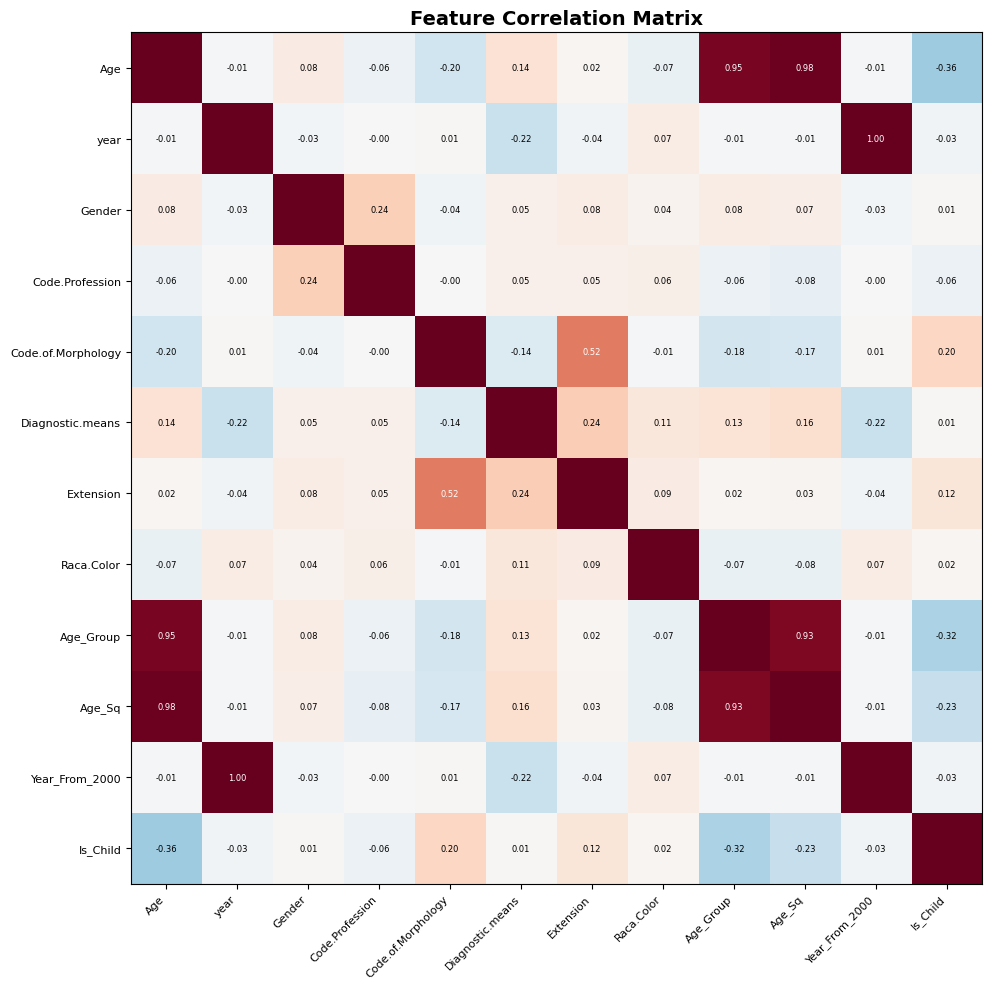

In [10]:

# --- 绘制相关性热力图 ---
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = plt.cm.RdBu_r
im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(n_feat))
ax.set_yticks(range(n_feat))
ax.set_xticklabels(all_features, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(all_features, fontsize=8)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

for i in range(n_feat):
    for j in range(n_feat):
        if i != j:
            val = corr_matrix.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color=color)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08a_correlation_matrix.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08a_correlation_matrix.png → 相关性矩阵已保存")

# 第二层: VIF (Variance Inflation Factor) — 多重共线性诊断

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [12]:

X_vif = X_imp_df[features_after_corr].copy()
# 添加截距项
X_vif_sm = sm.add_constant(X_vif)

vif_data = []
remaining = list(features_after_corr)

# 迭代删除高 VIF 特征
vif_removed = []
for iteration in range(20):
    if len(remaining) < 2:
        break
    X_sub = X_imp_df[remaining].copy()
    X_sub_sm = sm.add_constant(X_sub)

    vif_vals = []
    for i, col in enumerate(remaining):
        try:
            vif_val = variance_inflation_factor(X_sub_sm.values, i + 1)  # +1 for const
        except Exception:
            vif_val = np.inf
        vif_vals.append((col, vif_val))

    max_vif = max(vif_vals, key=lambda x: x[1])
    vif_data.extend(vif_vals)

    if max_vif[1] > 10:
        vif_removed.append((max_vif[0], max_vif[1], iteration + 1))
        remaining.remove(max_vif[0])
        print(f"    第{iteration+1}轮: 移除 {max_vif[0]} (VIF = {max_vif[1]:.2f} > 10)")
    else:
        print(f"    第{iteration+1}轮: 所有特征 VIF ≤ 10 (最高 VIF = {max_vif[1]:.2f})")
        break

features_after_vif = remaining
print(f"\n  VIF 筛选后保留: {len(features_after_vif)} / {len(features_after_corr)} 个特征")
print(f"  保留特征: {features_after_vif}")

    第1轮: 所有特征 VIF ≤ 10 (最高 VIF = 1.64)

  VIF 筛选后保留: 9 / 9 个特征
  保留特征: ['Gender', 'Code.Profession', 'Code.of.Morphology', 'Diagnostic.means', 'Extension', 'Raca.Color', 'Age_Sq', 'Year_From_2000', 'Is_Child']


  [图] 08b_vif_analysis.png → VIF 分析图已保存


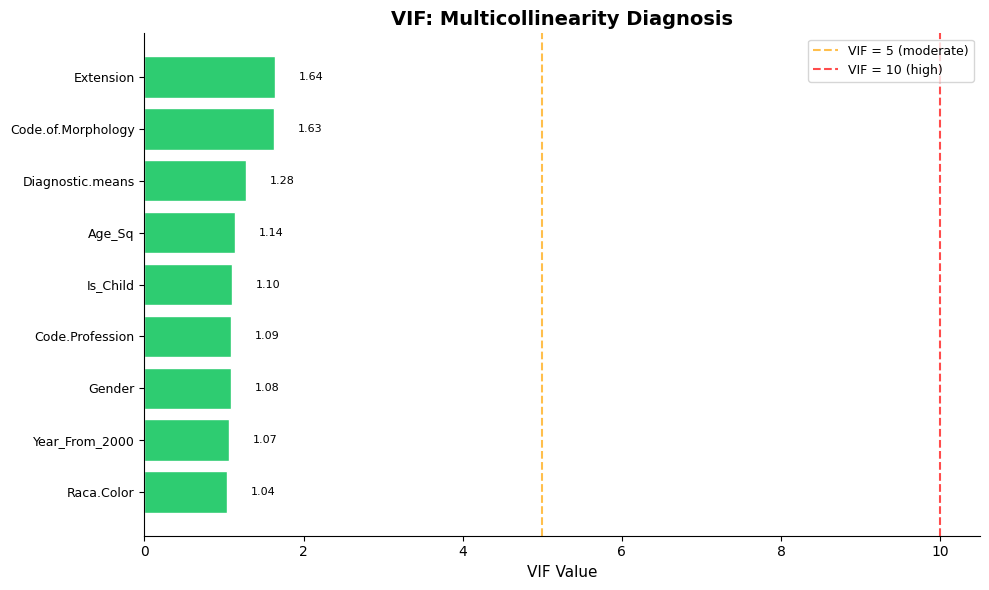

In [13]:
# --- 绘制 VIF 对比图 ---
vif_df = pd.DataFrame(vif_data, columns=['Feature', 'VIF'])
vif_df = vif_df.drop_duplicates(subset='Feature', keep='last')
vif_df = vif_df.sort_values('VIF', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_vif = ['#e74c3c' if v > 10 else ('#f39c12' if v > 5 else '#2ecc71')
              for v in vif_df['VIF']]
bars = ax.barh(range(len(vif_df)), vif_df['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='VIF = 5 (moderate)')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='VIF = 10 (high)')
ax.set_yticks(range(len(vif_df)))
ax.set_yticklabels(vif_df['Feature'], fontsize=9)
ax.set_xlabel('VIF Value', fontsize=11)
ax.set_title('VIF: Multicollinearity Diagnosis', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, v in zip(bars, vif_df['VIF']):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08b_vif_analysis.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08b_vif_analysis.png → VIF 分析图已保存")

# 第三层: Filter 方法 — ANOVA + Mutual Information

In [14]:

# ANOVA F-test
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_train_s, y_train)
anova_scores = anova_selector.scores_

# Mutual Information
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)

# 合并结果
filter_df = pd.DataFrame({
    'Feature': all_features,
    'ANOVA_F': anova_scores,
    'ANOVA_Rank': np.argsort(np.argsort(-anova_scores)) + 1,
    'MI': mi_scores,
    'MI_Rank': np.argsort(np.argsort(-mi_scores)) + 1,
    'Avg_Rank': (np.argsort(np.argsort(-anova_scores)) +
                  np.argsort(np.argsort(-mi_scores))) / 2 + 1
}).sort_values('Avg_Rank')

print(f"\n  {'特征':<22} {'ANOVA F':>10} {'ANOVA排名':>8} {'MI':>10} {'MI排名':>6} {'平均排名':>8}")
print(f"  {'-'*22} {'-'*10} {'-'*8} {'-'*10} {'-'*6} {'-'*8}")
for _, row in filter_df.iterrows():
    print(f"  {row['Feature']:<22} {row['ANOVA_F']:>10.1f} {int(row['ANOVA_Rank']):>8} "
          f"{row['MI']:>10.4f} {int(row['MI_Rank']):>6} {row['Avg_Rank']:>6.1f}")

top_filter_features = filter_df.head(int(np.ceil(n_feat * 0.6)))['Feature'].tolist()
print(f"\n  Filter 筛选 Top 60%: {top_filter_features}")


  特征                        ANOVA F  ANOVA排名         MI   MI排名     平均排名
  ---------------------- ---------- -------- ---------- ------ --------
  Diagnostic.means          15725.1        1     0.2361      2    1.5
  year                       4535.2        3     0.0923      3    3.0
  Year_From_2000             4535.2        2     0.0899      4    3.0
  Extension                  4303.8        4     0.0789      5    4.5
  Code.of.Morphology           62.9       11     0.2944      1    6.0
  Age                         978.0        6     0.0198      8    7.0
  Raca.Color                  685.0        8     0.0399      6    7.0
  Age_Sq                     1096.5        5     0.0191      9    7.0
  Code.Profession             647.9        9     0.0389      7    8.0
  Age_Group                   897.7        7     0.0172     10    8.5
  Gender                      305.8       10     0.0093     11   10.5
  Is_Child                      6.2       12     0.0005     12   12.0

  Filter 筛选 To

  [图] 08c_filter_methods.png → Filter 方法对比图已保存


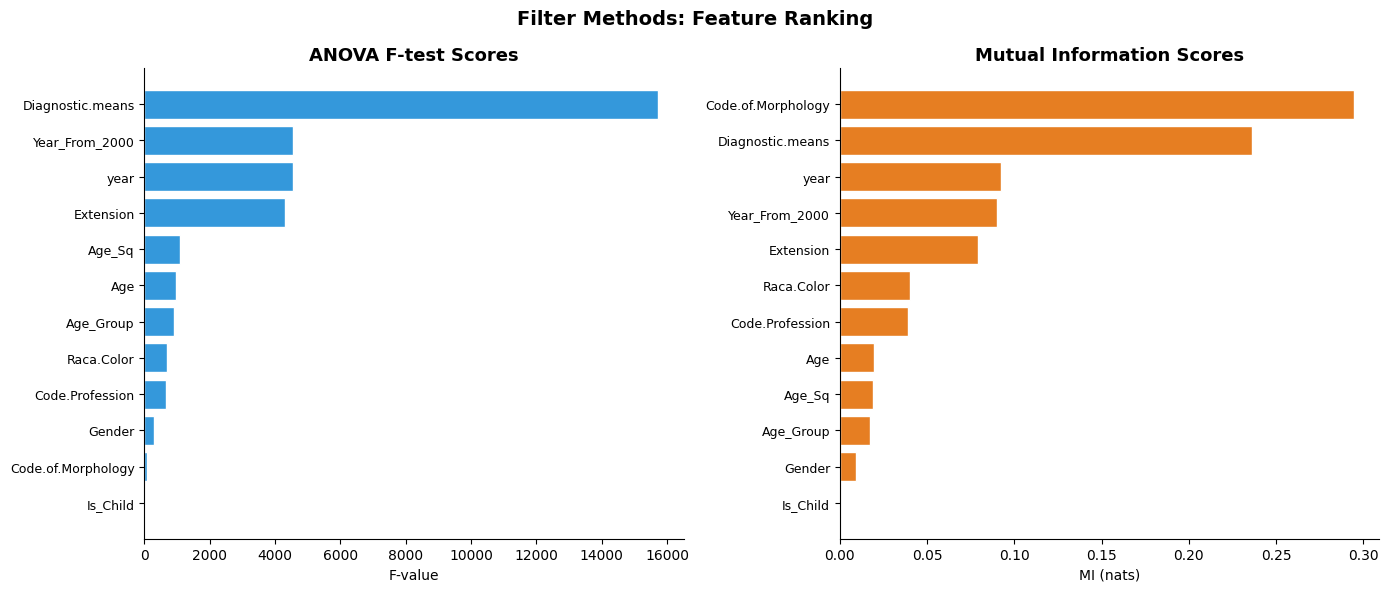

In [15]:
# --- 绘制 Filter 分数对比图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sorted_anova = filter_df.sort_values('ANOVA_F', ascending=True)
colors_a = ['#3498db'] * len(sorted_anova)
ax.barh(range(len(sorted_anova)), sorted_anova['ANOVA_F'], color='#3498db', edgecolor='white')
ax.set_yticks(range(len(sorted_anova)))
ax.set_yticklabels(sorted_anova['Feature'], fontsize=9)
ax.set_title('ANOVA F-test Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('F-value')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
sorted_mi = filter_df.sort_values('MI', ascending=True)
ax.barh(range(len(sorted_mi)), sorted_mi['MI'], color='#e67e22', edgecolor='white')
ax.set_yticks(range(len(sorted_mi)))
ax.set_yticklabels(sorted_mi['Feature'], fontsize=9)
ax.set_title('Mutual Information Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('MI (nats)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Filter Methods: Feature Ranking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08c_filter_methods.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08c_filter_methods.png → Filter 方法对比图已保存")

# 第四层: LASSO (L1 Regularization)

In [16]:

# 使用交叉验证选择最优 alpha
lasso_cv = LassoCV(
    cv=5,
    max_iter=10000,
    random_state=RANDOM_STATE,
    alphas=np.logspace(-4, 0, 50)
)
lasso_cv.fit(X_train_s, y_train)
best_alpha = lasso_cv.alpha_

# 用最优 alpha 重新训练
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=best_alpha, max_iter=10000, random_state=RANDOM_STATE)
lasso.fit(X_train_s, y_train)

lasso_coef = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lasso.coef_,
    'Abs_Coef': np.abs(lasso.coef_)
}).sort_values('Abs_Coef', ascending=False)

lasso_zero = lasso_coef[lasso_coef['Coefficient'] == 0]
lasso_nonzero = lasso_coef[lasso_coef['Coefficient'] != 0]

print(f"\n  最优 alpha (CV): {best_alpha:.6f}")
print(f"  被压缩为 0 的变量: {len(lasso_zero)} / {n_feat}")
for _, row in lasso_zero.iterrows():
    print(f"    — {row['Feature']}")
print(f"\n  非零系数的变量: {len(lasso_nonzero)} / {n_feat}")
for _, row in lasso_nonzero.iterrows():
    print(f"    + {row['Feature']:<22} coef = {row['Coefficient']:.6f}")

features_lasso = lasso_nonzero['Feature'].tolist()


  最优 alpha (CV): 0.000450
  被压缩为 0 的变量: 1 / 12
    — Age

  非零系数的变量: 11 / 12
    + Diagnostic.means       coef = -0.191430
    + Extension              coef = -0.130189
    + year                   coef = 0.119443
    + Code.of.Morphology     coef = 0.055030
    + Code.Profession        coef = -0.049555
    + Age_Sq                 coef = -0.045601
    + Raca.Color             coef = -0.043240
    + Is_Child               coef = -0.007589
    + Gender                 coef = -0.002845
    + Age_Group              coef = -0.002630
    + Year_From_2000         coef = 0.000027


  [图] 08d_lasso_analysis.png → LASSO 分析图已保存


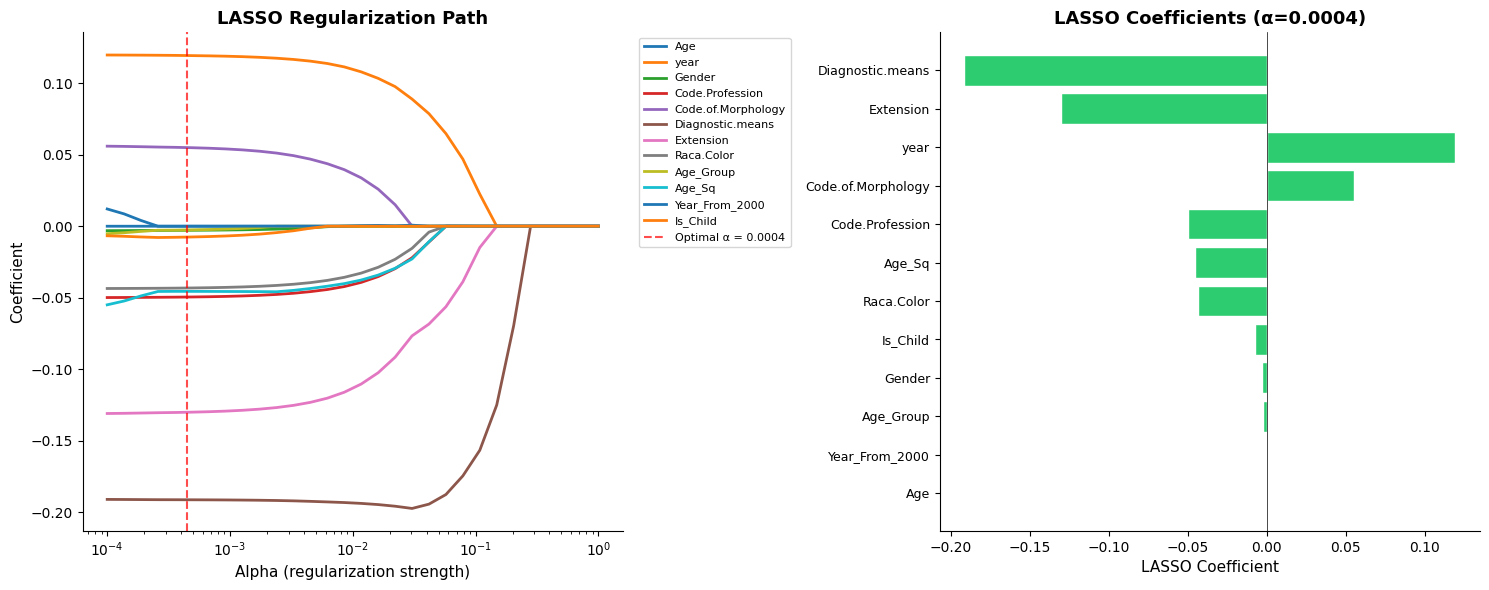

In [17]:
# --- 绘制 LASSO 路径图 ---
# 用不同的 alpha 展示系数变化路径
alphas_path = np.logspace(-4, 0, 30)
coef_path = []
for a in alphas_path:
    lasso_a = Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE)
    lasso_a.fit(X_train_s, y_train)
    coef_path.append(lasso_a.coef_)

coef_path = np.array(coef_path)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for i, feat in enumerate(all_features):
    ax.plot(alphas_path, coef_path[:, i], label=feat, linewidth=2)
ax.set_xscale('log')
ax.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.7,
           label=f'Optimal α = {best_alpha:.4f}')
ax.set_xlabel('Alpha (regularization strength)', fontsize=11)
ax.set_ylabel('Coefficient', fontsize=11)
ax.set_title('LASSO Regularization Path', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
features_sorted = lasso_coef.sort_values('Abs_Coef', ascending=True)
colors_l = ['#e74c3c' if c == 0 else '#2ecc71' for c in features_sorted['Coefficient']]
bars = ax.barh(range(len(features_sorted)), features_sorted['Coefficient'],
               color=colors_l, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted['Feature'], fontsize=9)
ax.set_xlabel('LASSO Coefficient', fontsize=11)
ax.set_title(f'LASSO Coefficients (α={best_alpha:.4f})', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08d_lasso_analysis.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08d_lasso_analysis.png → LASSO 分析图已保存")

# 第五层: Random Forest Importance

In [18]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n  {'特征':<22} {'重要性':>10} {'累积':>8}")
print(f"  {'-'*22} {'-'*10} {'-'*8}")
cumsum = 0
for _, row in rf_importance.iterrows():
    cumsum += row['Importance']
    print(f"  {row['Feature']:<22} {row['Importance']:>10.4f} {cumsum:>7.1%}")

# 选取累积重要性达 90% 的特征
cumulative = 0
rf_top_features = []
for _, row in rf_importance.iterrows():
    cumulative += row['Importance']
    rf_top_features.append(row['Feature'])
    if cumulative >= 0.90:
        break

features_rf = rf_top_features
print(f"\n  Top 特征 (累积 ≥ 90%): {features_rf}")


  特征                            重要性       累积
  ---------------------- ---------- --------
  Diagnostic.means           0.3198   32.0%
  Code.of.Morphology         0.2526   57.2%
  Extension                  0.1079   68.0%
  year                       0.1042   78.5%
  Year_From_2000             0.0998   88.4%
  Raca.Color                 0.0333   91.8%
  Code.Profession            0.0255   94.3%
  Age                        0.0221   96.5%
  Age_Sq                     0.0212   98.6%
  Age_Group                  0.0075   99.4%
  Gender                     0.0058  100.0%
  Is_Child                   0.0003  100.0%

  Top 特征 (累积 ≥ 90%): ['Diagnostic.means', 'Code.of.Morphology', 'Extension', 'year', 'Year_From_2000', 'Raca.Color']


  [图] 08e_rf_importance.png → 随机森林重要性图已保存


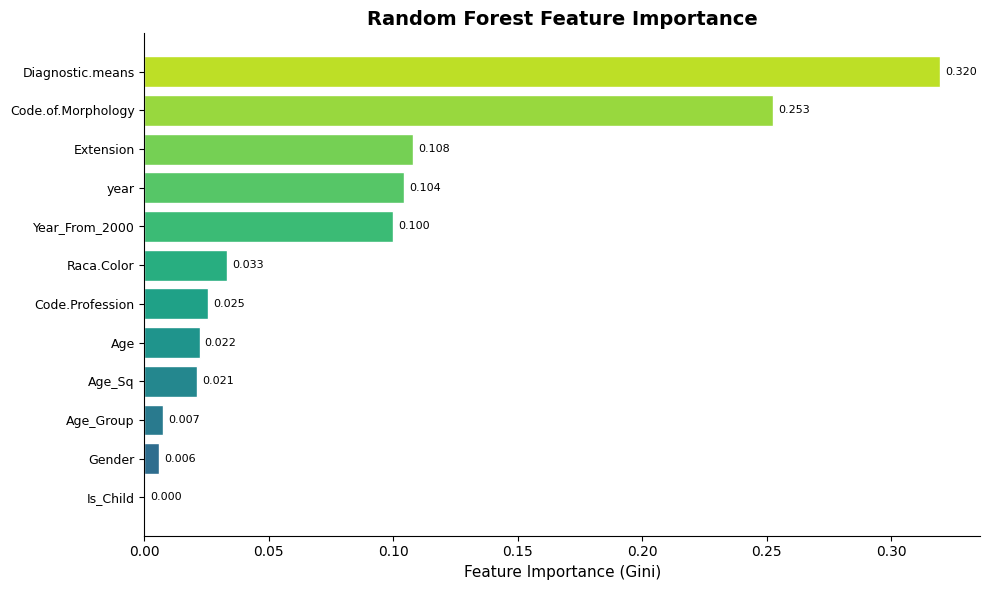

In [19]:
# --- 绘制 RF 重要性图 ---
fig, ax = plt.subplots(figsize=(10, 6))
plot_rf = rf_importance.sort_values('Importance', ascending=True)
colors_rf = plt.cm.viridis(np.linspace(0.3, 0.9, len(plot_rf)))
bars = ax.barh(range(len(plot_rf)), plot_rf['Importance'], color=colors_rf, edgecolor='white')
ax.set_yticks(range(len(plot_rf)))
ax.set_yticklabels(plot_rf['Feature'], fontsize=9)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, v in zip(bars, plot_rf['Importance']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08e_rf_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08e_rf_importance.png → 随机森林重要性图已保存")

# 第六层: Boruta — 真实变量与随机变量竞争

In [20]:

# Boruta 需要 Random Forest 作为估计器
rf_boruta = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

boruta = BorutaPy(
    rf_boruta,
    n_estimators='auto',
    perc=100,
    alpha=0.05,
    random_state=RANDOM_STATE,
    max_iter=20
)

print("\n  运行 Boruta (可能需要一些时间)...")
start_boruta = time.time()
boruta.fit(X_train, y_train)
elapsed_boruta = time.time() - start_boruta
print(f"  Boruta 完成! 耗时: {elapsed_boruta:.1f}s")

boruta_result = pd.DataFrame({
    'Feature': all_features,
    'Support': boruta.support_,
    'Support_Weak': boruta.support_weak_,
    'Rank': boruta.ranking_
})

confirmed = boruta_result[boruta_result['Support']].sort_values('Rank')
tentative = boruta_result[~boruta_result['Support'] & boruta_result['Support_Weak']].sort_values('Rank')
rejected = boruta_result[~boruta_result['Support'] & ~boruta_result['Support_Weak']].sort_values('Rank')

print(f"\n  Boruta 结果:")
print(f"  ✅ Confirmed (确认): {len(confirmed)} 个")
for _, row in confirmed.iterrows():
    print(f"      + {row['Feature']:<22} (rank={int(row['Rank'])})")

print(f"\n  ⚠️  Tentative (暂定): {len(tentative)} 个")
for _, row in tentative.iterrows():
    print(f"      ~ {row['Feature']:<22} (rank={int(row['Rank'])})")

print(f"\n  ❌ Rejected (拒绝): {len(rejected)} 个")
for _, row in rejected.iterrows():
    print(f"      - {row['Feature']:<22} (rank={int(row['Rank'])})")

features_boruta = confirmed['Feature'].tolist()


  运行 Boruta (可能需要一些时间)...
  Boruta 完成! 耗时: 1.4s

  Boruta 结果:
  ✅ Confirmed (确认): 11 个
      + Age                    (rank=1)
      + year                   (rank=1)
      + Gender                 (rank=1)
      + Code.Profession        (rank=1)
      + Code.of.Morphology     (rank=1)
      + Diagnostic.means       (rank=1)
      + Extension              (rank=1)
      + Raca.Color             (rank=1)
      + Age_Group              (rank=1)
      + Age_Sq                 (rank=1)
      + Year_From_2000         (rank=1)

  ⚠️  Tentative (暂定): 0 个

  ❌ Rejected (拒绝): 1 个
      - Is_Child               (rank=2)


  [图] 08f_boruta_results.png → Boruta 结果图已保存


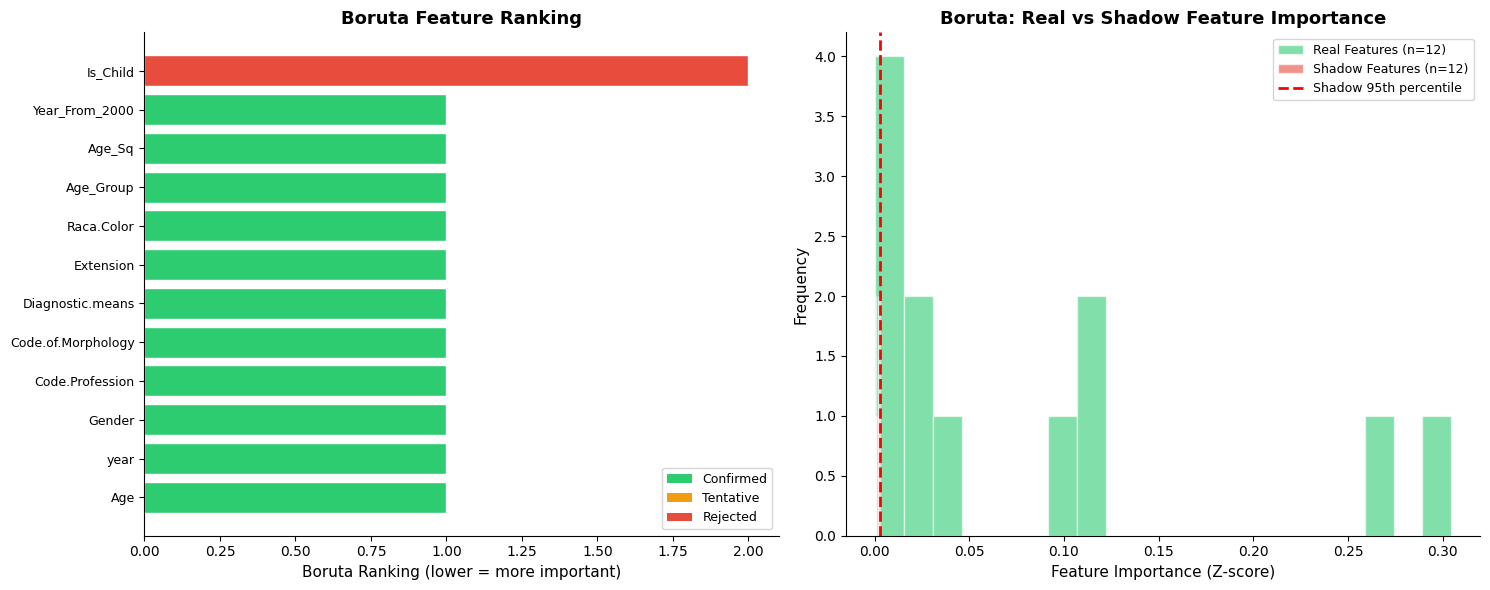

In [21]:

# --- 绘制 Boruta 结果图 ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
boruta_plot = boruta_result.sort_values('Rank', ascending=True)
colors_boruta = []
for _, row in boruta_plot.iterrows():
    if row['Support']:
        colors_boruta.append('#2ecc71')
    elif row['Support_Weak']:
        colors_boruta.append('#f39c12')
    else:
        colors_boruta.append('#e74c3c')

bars = ax.barh(range(len(boruta_plot)), boruta_plot['Rank'],
               color=colors_boruta, edgecolor='white')
ax.set_yticks(range(len(boruta_plot)))
ax.set_yticklabels(boruta_plot['Feature'], fontsize=9)
ax.set_xlabel('Boruta Ranking (lower = more important)', fontsize=11)
ax.set_title('Boruta Feature Ranking', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Confirmed'),
    Patch(facecolor='#f39c12', label='Tentative'),
    Patch(facecolor='#e74c3c', label='Rejected')
]
ax.legend(handles=legend_elements, fontsize=9)

# Boruta 决策边界可视化 — Shadow feature method
# BorutaPy 不直接暴露重要性, 绘制决策过程近似图
ax = axes[1]
# 使用 RandomForest 的特征重要性近似 Boruta 的决策过程
rf_short = RandomForestClassifier(n_estimators=100, max_depth=8,
                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
# 在原始数据 + 打乱副本上训练, 模拟阴影特征
X_train_shuffled = X_train.copy()
np.random.seed(RANDOM_STATE)
for col in range(X_train_shuffled.shape[1]):
    np.random.shuffle(X_train_shuffled[:, col])
X_train_shadow = np.hstack([X_train, X_train_shuffled])
rf_short.fit(X_train_shadow, y_train)
shadow_importances = rf_short.feature_importances_

n_real = len(all_features)
real_imp = shadow_importances[:n_real]
shadow_imp = shadow_importances[n_real:]

ax.hist(real_imp, bins=20, alpha=0.6, color='#2ecc71', edgecolor='white',
        label=f'Real Features (n={n_real})')
ax.hist(shadow_imp, bins=20, alpha=0.6, color='#e74c3c', edgecolor='white',
        label=f'Shadow Features (n={n_real})')
shadow_95 = np.percentile(shadow_imp, 95)
ax.axvline(x=shadow_95, color='red', linestyle='--',
           linewidth=2, label='Shadow 95th percentile')
ax.set_xlabel('Feature Importance (Z-score)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Boruta: Real vs Shadow Feature Importance',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08f_boruta_results.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08f_boruta_results.png → Boruta 结果图已保存")


  方法                                 保留     删除
  ------------------------------ ------ ------
  Layer 1: Correlation                9      3
  Layer 2: VIF                        9      0
  Layer 3: Filter (ANOVA+MI)          8      4
  Layer 4: LASSO                     11      1
  Layer 5: RF Importance              6      6
  Layer 6: Boruta                    11      1
  [图] 08g_selection_summary.png → 六层选择汇总图已保存


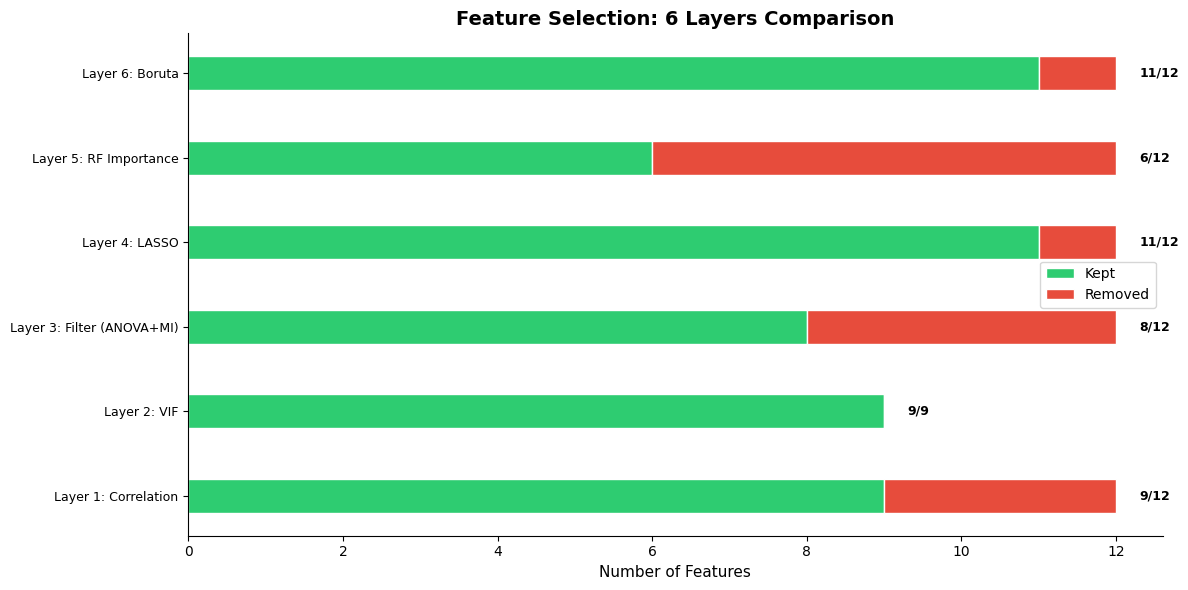

In [22]:
selection_summary = {
    'Layer 1: Correlation': {
        '保留': len(features_after_corr),
        '删除': n_feat - len(features_after_corr),
        '保留特征': features_after_corr
    },
    'Layer 2: VIF': {
        '保留': len(features_after_vif),
        '删除': len(features_after_corr) - len(features_after_vif),
        '保留特征': features_after_vif
    },
    'Layer 3: Filter (ANOVA+MI)': {
        '保留': len(top_filter_features),
        '删除': n_feat - len(top_filter_features),
        '保留特征': top_filter_features
    },
    'Layer 4: LASSO': {
        '保留': len(features_lasso),
        '删除': n_feat - len(features_lasso),
        '保留特征': features_lasso
    },
    'Layer 5: RF Importance': {
        '保留': len(features_rf),
        '删除': n_feat - len(features_rf),
        '保留特征': features_rf
    },
    'Layer 6: Boruta': {
        '保留': len(features_boruta),
        '删除': n_feat - len(features_boruta),
        '保留特征': features_boruta
    }
}

print(f"\n  {'方法':<30} {'保留':>6} {'删除':>6}")
print(f"  {'-'*30} {'-'*6} {'-'*6}")
for method, info in selection_summary.items():
    print(f"  {method:<30} {info['保留']:>6} {info['删除']:>6}")


# --- 绘制六层汇总图 ---
fig, ax = plt.subplots(figsize=(12, 6))

all_methods = list(selection_summary.keys())
y_pos = np.arange(len(all_methods))
kept = [selection_summary[m]['保留'] for m in all_methods]
removed = [selection_summary[m]['删除'] for m in all_methods]

ax.barh(y_pos, kept, height=0.4, color='#2ecc71', edgecolor='white', label='Kept')
ax.barh(y_pos, removed, height=0.4, left=kept,
        color='#e74c3c', edgecolor='white', label='Removed')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_methods, fontsize=9)
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_title('Feature Selection: 6 Layers Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

for i, (k, r) in enumerate(zip(kept, removed)):
    ax.text(k + r + 0.3, i, f'{k}/{k+r}', va='center', fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08g_selection_summary.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08g_selection_summary.png → 六层选择汇总图已保存")

 


# 验证: 各层选择的特征集在 Logistic Regression 上的表现

  All Features              n=12  AUC=0.8980  Recall=0.8874  Brier=0.1281
  Correlation               n= 9  AUC=0.8980  Recall=0.8871  Brier=0.1281
  Corr+VIF                  n= 9  AUC=0.8980  Recall=0.8871  Brier=0.1281
  Filter(ANOVA+MI)          n= 8  AUC=0.8926  Recall=0.8957  Brier=0.1310
  LASSO                     n=11  AUC=0.8980  Recall=0.8874  Brier=0.1281
  RF Importance             n= 6  AUC=0.8883  Recall=0.8996  Brier=0.1342
  Boruta                    n=11  AUC=0.8979  Recall=0.8872  Brier=0.1281
  [图] 08h_validation_roc.png → 验证 ROC 曲线已保存
  [图] 08i_validation_performance.png → 验证性能对比图已保存


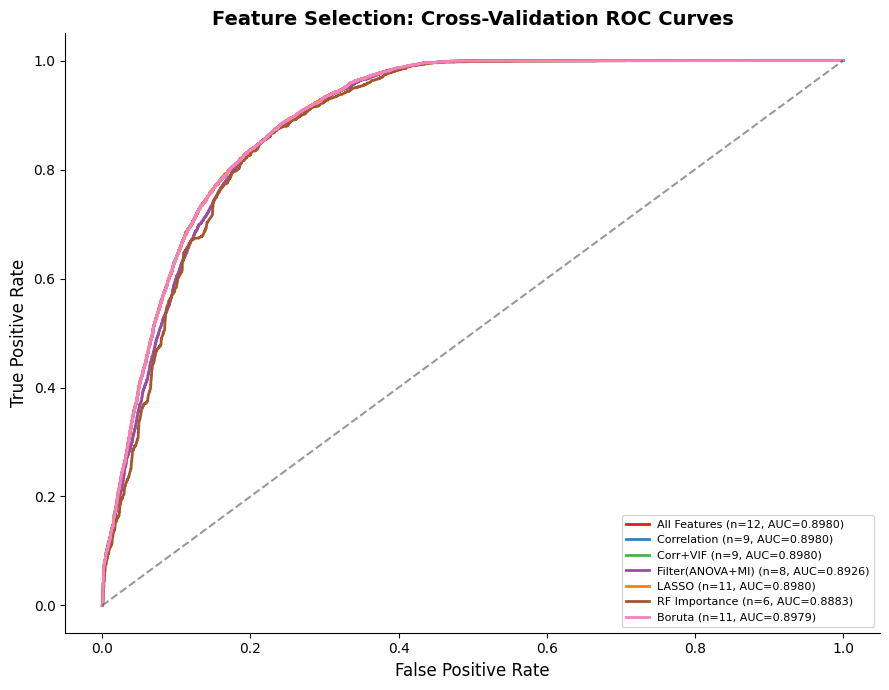

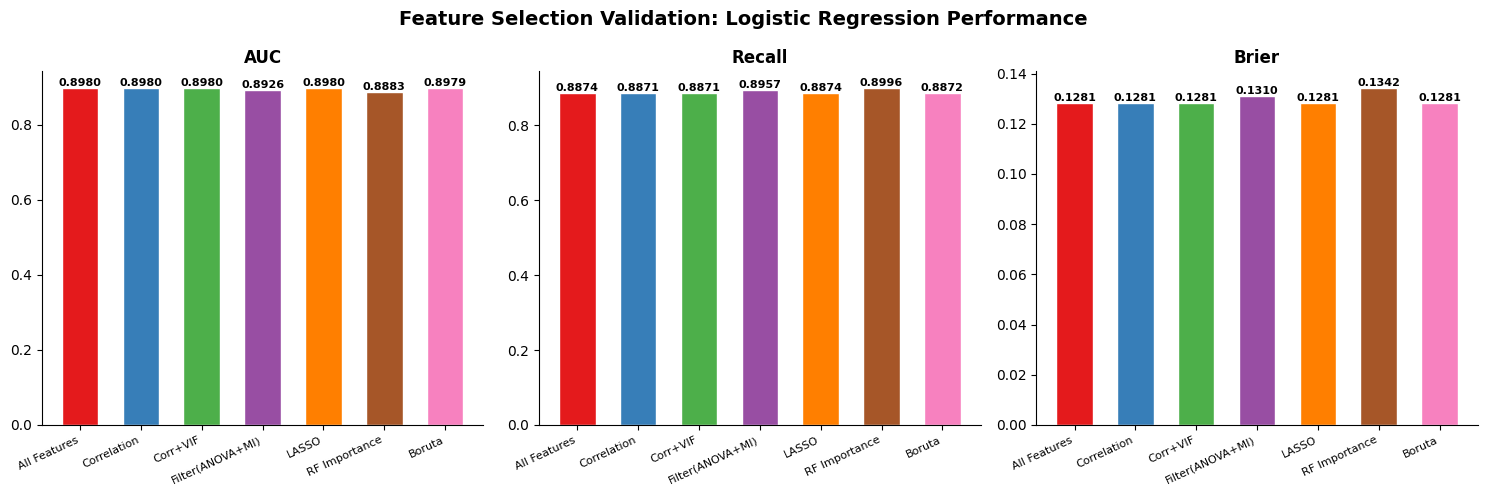

In [23]:

feature_sets = {
    'All Features': all_features,
    'Correlation': features_after_corr,
    'Corr+VIF': features_after_vif,
    'Filter(ANOVA+MI)': top_filter_features,
    'LASSO': features_lasso,
    'RF Importance': features_rf,
    'Boruta': features_boruta
}

validation_results = []

fig, ax_roc = plt.subplots(figsize=(9, 7))
colors_val = plt.cm.Set1(np.linspace(0, 0.8, len(feature_sets)))

for (name, feat_list), color in zip(feature_sets.items(), colors_val):
    if len(feat_list) == 0:
        continue

    idxs = [all_features.index(f) for f in feat_list if f in all_features]
    X_tr = X_train_s[:, idxs]
    X_te = X_test_s[:, idxs]

    lr = LogisticRegression(class_weight='balanced', max_iter=5000,
                            random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_tr, y_train)
    y_prob = lr.predict_proba(X_te)[:, 1]
    y_pred = lr.predict(X_te)

    auc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred, pos_label=1)
    brier = brier_score_loss(y_test, y_prob)

    validation_results.append({
        'Feature_Set': name,
        'N_Features': len(feat_list),
        'AUC': auc,
        'Recall': rec,
        'Brier': brier
    })

    print(f"  {name:<25} n={len(feat_list):>2}  AUC={auc:.4f}  Recall={rec:.4f}  Brier={brier:.4f}")

    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{name} (n={len(feat_list)}, AUC={auc:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('Feature Selection: Cross-Validation ROC Curves',
                 fontsize=14, fontweight='bold')
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.spines['top'].set_visible(False)
ax_roc.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08h_validation_roc.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08h_validation_roc.png → 验证 ROC 曲线已保存")

# 保存验证结果
val_df = pd.DataFrame(validation_results)
val_df.to_csv(os.path.join(RESULTS_DIR, "11_feature_selection_validation.csv"),
              index=False, encoding='utf-8-sig')

# 性能对比图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['AUC', 'Recall', 'Brier']):
    ax = axes[i]
    names = [r['Feature_Set'] for r in validation_results]
    vals = [r[metric] for r in validation_results]
    bars = ax.bar(range(len(names)), vals, color=colors_val, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Feature Selection Validation: Logistic Regression Performance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "08i_validation_performance.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 08i_validation_performance.png → 验证性能对比图已保存")

 